In [16]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [11]:
real_bars = pd.read_csv('/Users/rm026/Documents/msa/msa_local_filelist_w_baseline_info.csv')
ground_truth = pd.read_csv('/Users/rm026/Documents/code/reviewpyper_testing/unredacted_msa_ground_truth_w_maybes.csv')
ground_truth.replace({2:0}, inplace=True)
bars_cols=list(ground_truth.columns)[2:]
ground_truth['mean']=ground_truth[bars_cols].mean(axis=1)
ground_truth

,MRN,Fake MRN,"Does this patient have difficulty walking? For instance, they may mention the patient staggering, difficulties in half turn, requiring support from a wall or stick, or being entirely unable to walk on their own.","Does this patient have difficulty performing the heel-shin maneuver? For instance, they may mention that the patient lowers their heel jerkily, abnormally slowly, or with lateral movements.","Does this patient have difficulty performing the finger-nose maneuver? For instance, they may mention that the patient shows dysmetria, oscillating movement, or segmented movement of the arm or hand.","Does this patient’s speech show dysarthria or slurring? For instance, the text may mention impairment of rate, rhythm, or clarity, not being able to understand the patient, or having to ask the patient to repeat themselves multiple times.","Does this patient have oculomotor abnormalities? For example, the text may mention slowed pursuit, saccadic intrusions, hypo/hypermetric saccade, or nystagmus.",mean
0,10087609,1,1,1,1,1,1,1.0
1,18337527,0,1,1,1,1,1,1.0
2,22159321,3,1,1,1,1,0,0.8
3,22171516,4,1,1,1,1,1,1.0
4,26860551,5,1,1,1,1,0,0.8
5,29828050,6,1,0,1,0,1,0.6
6,33585787,7,1,0,0,1,1,0.6
7,39983424,8,1,0,0,1,1,0.6
8,40204844,9,1,0,1,1,1,0.8
9,42261594,10,1,1,1,1,1,1.0


In [ ]:
mylist=[]
for sub in real_bars['MRN'].unique():
    mydf=real_bars[real_bars['MRN']==sub]
    max_bars=mydf['BARS'].max()
    
    if np.isnan(max_bars):
        continue
    fakes=ground_truth[ground_truth['MRN']==sub]['mean']
    if len(fakes)==0:
        print(sub)
        continue

    mylist.append([sub, mydf['BARS'].max(), fakes.values[0]])
df=pd.DataFrame(mylist, columns=['mrn','bars','psuedo-bars'])
df

26815373
15577414


,mrn,bars,psuedo-bars
0,33585787,8.0,0.6
1,10087609,29.6,1.0
2,42261594,18.5,1.0
3,22171516,20.5,1.0
4,18337527,10.5,1.0
5,22159321,23.0,0.8
6,40204844,11.0,0.8
7,42862441,5.0,1.0
8,49444755,5.5,0.6
9,45832631,12.0,1.0


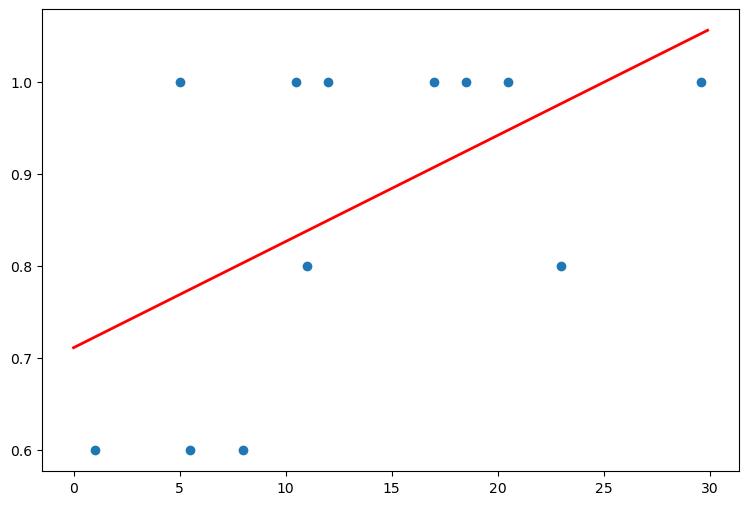

In [61]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['bars'], df['psuedo-bars'])

# Fit linear regression via least squares with numpy.polyfit
# It returns an slope (b) and intercept (a)
# deg=1 means linear fit (i.e. polynomial of degree 1)
b, a = np.polyfit(df['bars'], df['psuedo-bars'], deg=1)

# Create sequence of 100 numbers from 0 to 100
xseq = np.arange(0,30,.1 )

# Plot regression line
ax.plot(xseq, a + b * xseq, color='red', lw=2)

In [55]:
b

0.011530002061997379

In [43]:
r=np.corrcoef(df['bars'], df['psuedo-bars'])
r

array([[1.        , 0.54549312],
       [0.54549312, 1.        ]])

In [51]:
import statsmodels.api as sm
model = sm.GLM(df['bars'], df['psuedo-bars'], family=sm.families.Gaussian())

results = model.fit()

print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   bars   No. Observations:                   12
Model:                            GLM   Df Residuals:                       11
Model Family:                Gaussian   Df Model:                            0
Link Function:               Identity   Scale:                          52.751
Method:                          IRLS   Log-Likelihood:                -40.299
Date:                Wed, 08 Oct 2025   Deviance:                       580.26
Time:                        17:05:47   Pearson chi2:                     580.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.2686
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
psuedo-bars    15.9188      2.374      6.706      